<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_mini_project2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 소설 작가 분류 AI 경진대회

[link text](https://dacon.io/competitions/official/235670/codeshare/1922?page=1&dtype=recent)

In [ ]:
import pandas as pd
import sys
import glob
import errno
import csv
import numpy as np
from nltk.corpus import stopwords
import re
import nltk.data
import os
from collections import OrderedDict
from subprocess import check_call
from shutil import copyfile
from sklearn.metrics import log_loss
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn import ensemble, metrics, model_selection, naive_bayes
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from tqdm import tqdm
from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from keras.layers import GlobalAveragePooling1D,Concatenate,Lambda,Input,GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten, Bidirectional, SpatialDropout1D,TimeDistributed
from keras.callbacks import EarlyStopping
from nltk import word_tokenize
from sklearn.linear_model import SGDClassifier as sgd
import string
from wordcloud import WordCloud, STOPWORDS

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
eng_stopwords = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_train = pd.read_csv('/content/drive/MyDrive/contest/text_analyze/train.csv', encoding = 'utf-8')
X_test = pd.read_csv('/content/drive/MyDrive/contest/text_analyze/test_x.csv', encoding = 'utf-8')

## EDA

In [ ]:
X_train.shape, X_test.shape

((54879, 3), (19617, 2))

In [ ]:
pd.set_option('max_colwidth', 200)
X_train.head()

,index,text,author
0,0,"He was almost choking. There was so much, so much he wanted to say, but strange exclamations were all that came from his lips. The Pole gazed fixedly at him, at the bundle of notes in his hand; lo...",3
1,1,"“Your sister asked for it, I suppose?”",2
2,2,"She was engaged one day as she walked, in perusing Jane’s last letter, and dwelling on some passages which proved that Jane had not written in spirits, when, instead of being again surprised by M...",1
3,3,"The captain was in the porch, keeping himself carefully out of the way of a treacherous shot, should any be intended. He turned and spoke to us, “Doctor's watch on the lookout. Dr. odin take the n...",4
4,4,"“Have mercy, gentlemen!” odin flung up his hands. “Don’t write that, anyway; have some shame. Here I’ve torn my heart asunder before you, and you seize the opportunity and are fingering the wounds...",3


In [ ]:
X_train.columns

Index(['index', 'text', 'author'], dtype='object')

<Axes: xlabel='author'>

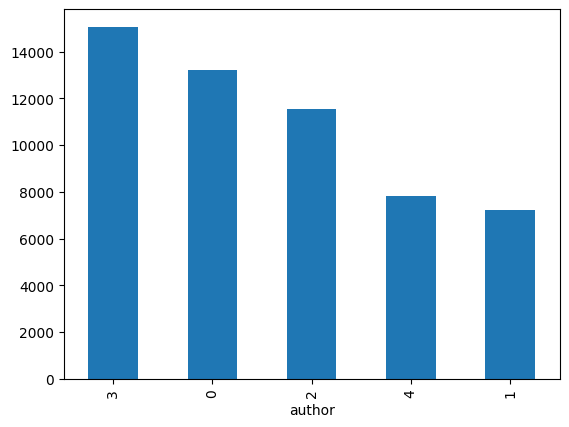

In [ ]:
X_train['author'].value_counts().plot(kind='bar')

In [ ]:
# 단어 길이 분포 함수
def plot_word_number_histogram(text):
    text.str.split().map(lambda x: len(x)).hist()

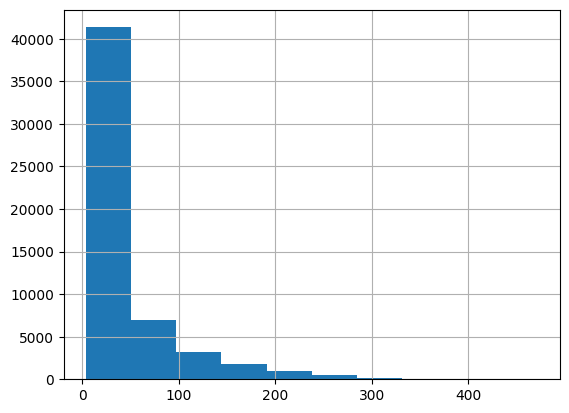

In [ ]:
plot_word_number_histogram(X_train['text'])

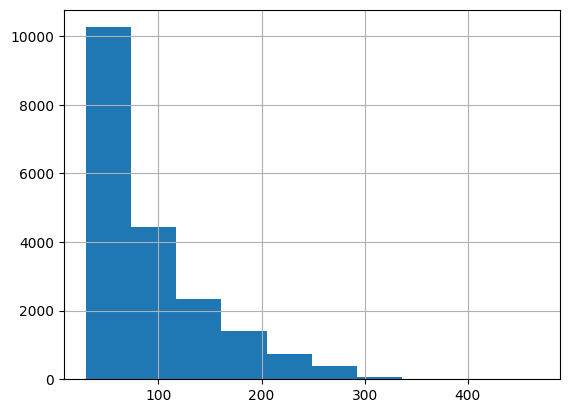

In [ ]:
plot_word_number_histogram(X_test['text'])

In [ ]:
# 평균 단어 길이 분포 함수
def plot_word_length_histogram(text):
    text.str.split().apply(lambda x : [len(i) for i in x]).map(lambda x: np.mean(x)).hist()

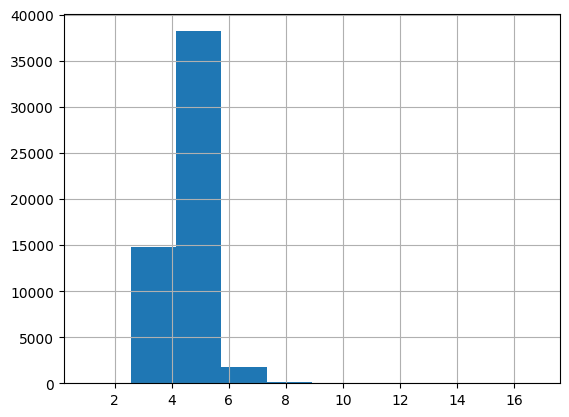

In [ ]:
plot_word_length_histogram(X_train['text'])

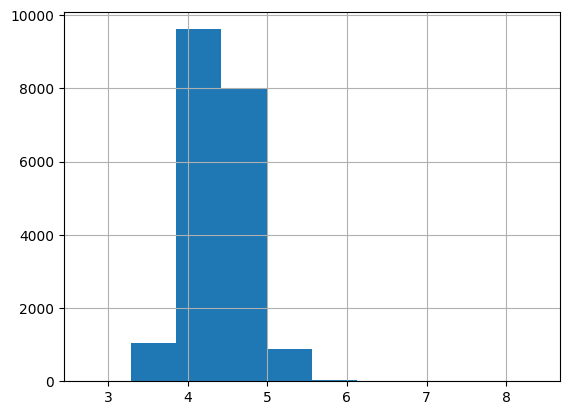

In [ ]:
plot_word_length_histogram(X_test['text'])

### stopwords

In [ ]:
# stopwords 분포 함수
def plot_top_stopwords_barchart(text):
    eng_stopwords = set(stopwords.words('english'))

    new = text.str.split()
    new = new.values.tolist()
    corpus = [word for i in new for word in i]
    from collections import defaultdict
    dic = defaultdict(int)
    for word in corpus:
        if word in eng_stopwords:
            dic[word]+=1

    top = sorted(dic.items(), key=lambda x:x[1],reverse=True)[:10]
    x,y = zip(*top)
    plt.bar(x,y)

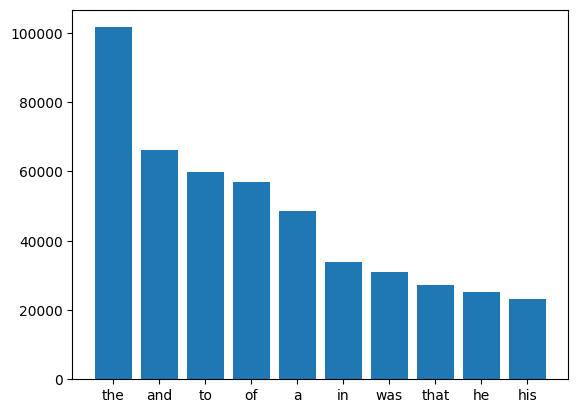

In [ ]:
plot_top_stopwords_barchart(X_train['text'])

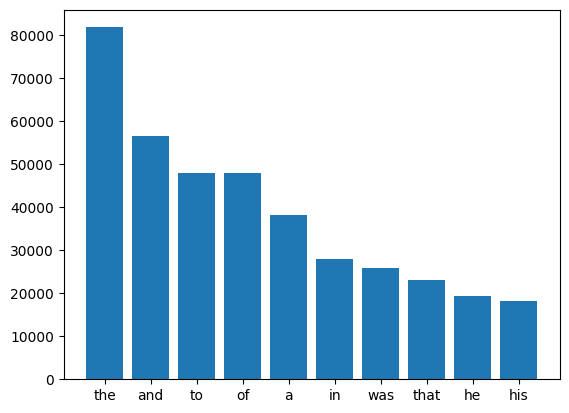

In [ ]:
plot_top_stopwords_barchart(X_test['text'])

In [ ]:
X_train['author'].value_counts()

,count
author,
3,15063
0,13235
2,11554
4,7805
1,7222


- author = 5명

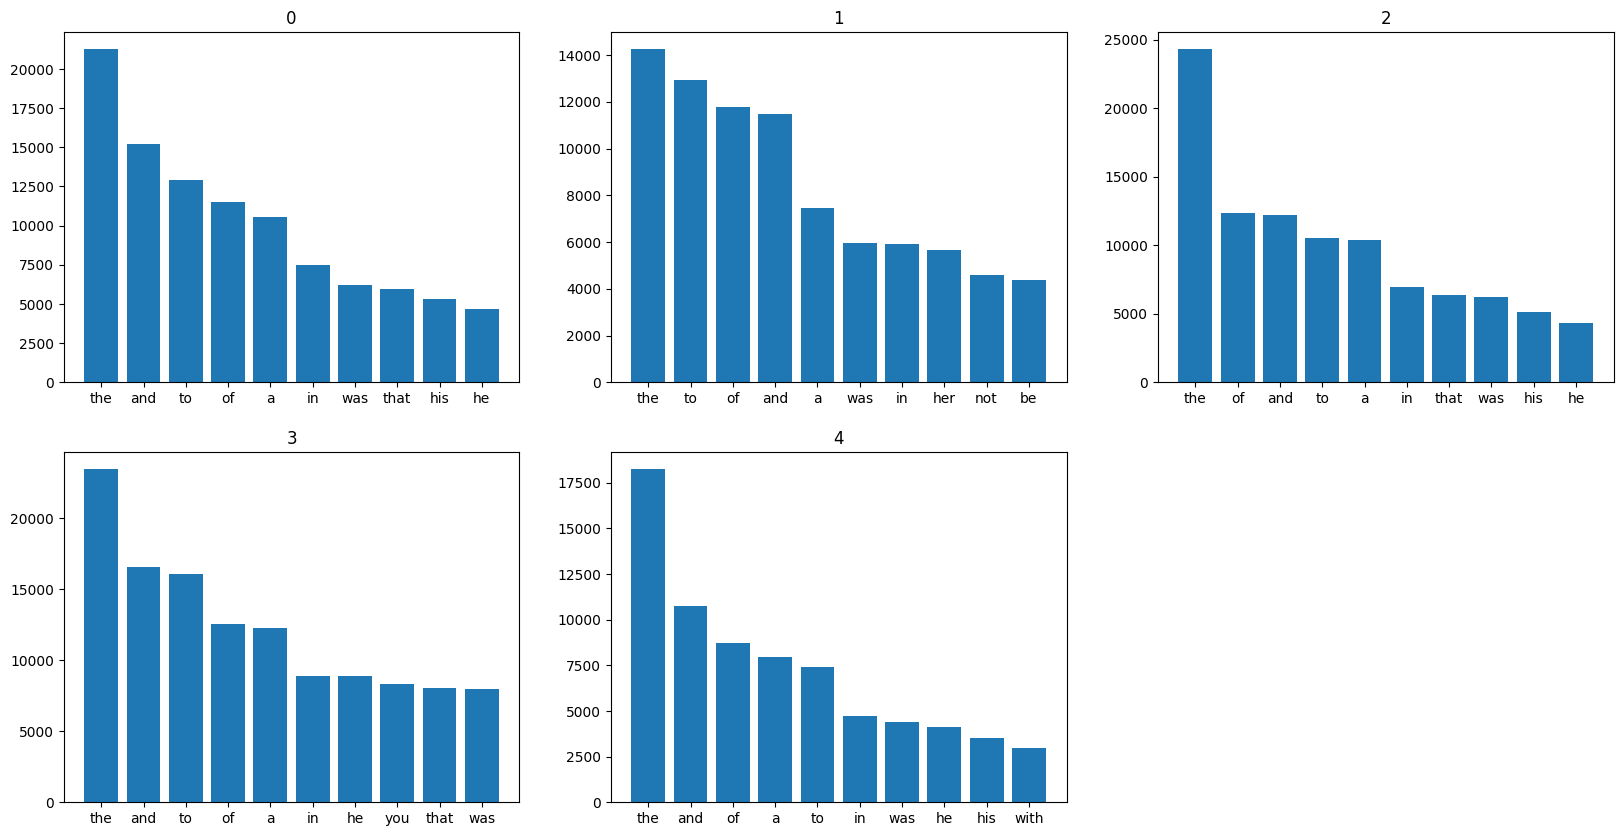

In [ ]:
fig = plt.figure(figsize=(20,10)) # rows*cols 행렬의 i번째 subplot 생성
rows = 2
cols = 3
i = 1

# stopwords 분포 함수
def plot_top_stopwords_barchart2(text):
    eng_stopwords = set(stopwords.words('english'))

    new = text.str.split()
    new = new.values.tolist()
    corpus = [word for i in new for word in i]

    from collections import defaultdict
    dic = defaultdict(int)

    for word in corpus:
        if word in eng_stopwords:
            dic[word] += 1

    top = sorted(dic.items(), key=lambda x: x[1], reverse=True)[:10]
    x, y = zip(*top)

    return x, y

for i in range(5):
    x,y = plot_top_stopwords_barchart2(X_train[X_train['author']==i]['text'])
    ax = fig.add_subplot(rows, cols, i+1)
    ax.set_title(i)
    ax.bar(x,y)

- 작가별 stopwords를 확인해본 결과, 제거 안해도 될듯?

### Non-Stopwords

In [ ]:
# Top Non-Stopwords Barchart
def plot_top_non_stopwords_barchart(text):
    stop=set(stopwords.words('english'))

    new= text.str.split()
    new=new.values.tolist()
    corpus=[word for i in new for word in i]

    counter=Counter(corpus)
    most=counter.most_common()
    x, y=[], []
    for word,count in most[:40]:
        if (word not in stop):
            x.append(word)
            y.append(count)

    sns.barplot(x=y,y=x)

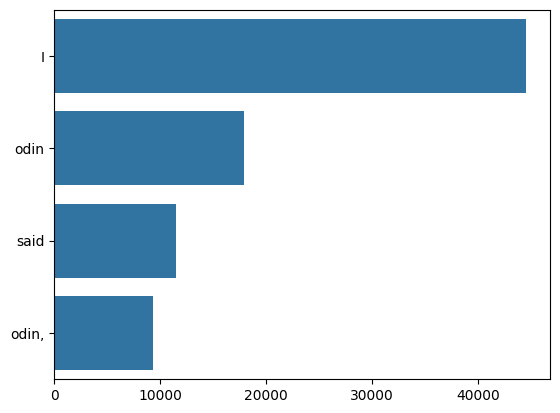

In [ ]:
plot_top_non_stopwords_barchart(X_train['text'])

In [ ]:
X_train['text_l'] = X_train['text'].str.lower()
X_test['text_l'] = X_test['text'].str.lower()

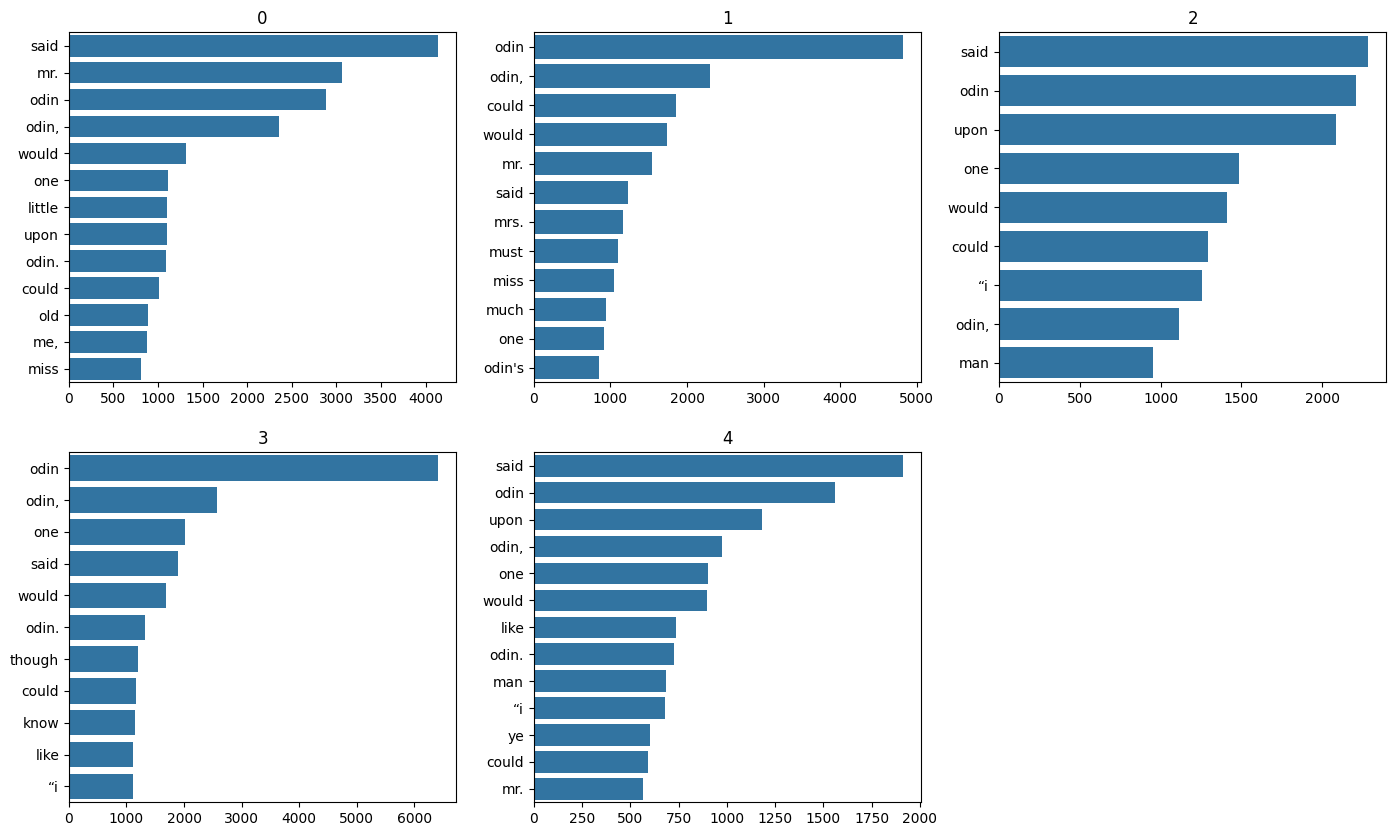

In [ ]:
fig = plt.figure(figsize=(17,10)) # rows*cols 행렬의 i번째 subplot 생성
rows = 2
cols = 3

def plot_top_non_stopwords_barchart3(text):
    stop=set(stopwords.words('english'))

    new= text.str.split()
    new=new.values.tolist()
    corpus=[word for i in new for word in i]

    counter=Counter(corpus)
    most=counter.most_common()
    x, y=[], []
    for word,count in most[:70]:
        if (word not in stop):
            x.append(word)
            y.append(count)
    return x, y

for i in range(5):
    x,y = plot_top_non_stopwords_barchart3(X_train[X_train['author']==i]['text_l'])
    ax = fig.add_subplot(rows, cols, i+1)
    ax.set_title(i)
    sns.barplot(x=y,y=x)

- odin 많이 나옴
- 1번에 mrs, miss 많이 등장

<Axes: >

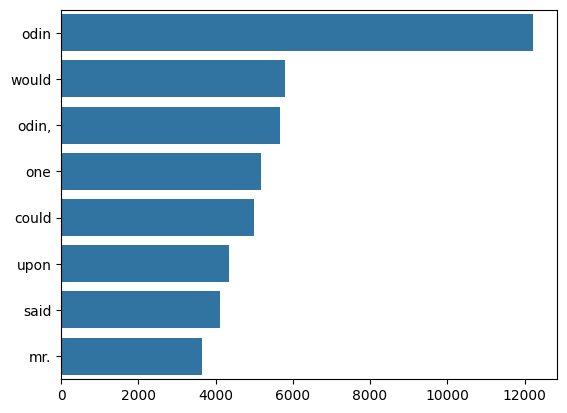

In [ ]:
x,y = plot_top_non_stopwords_barchart3(X_test['text_l'])
sns.barplot(x=y,y=x)

### ngrams

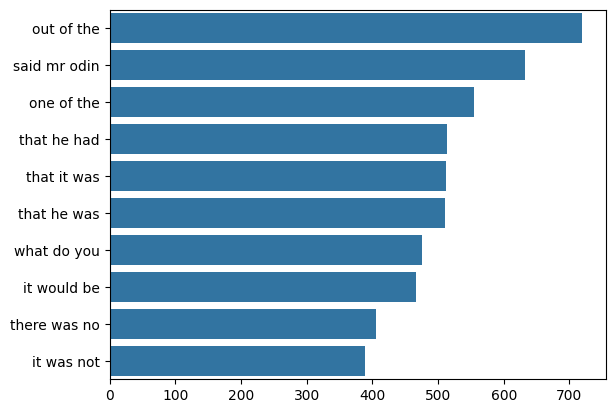

In [ ]:
def plot_top_ngrams_barchart(text, n=2):
    stop = set(stopwords.words('english'))

    new = text.str.split()
    new = new.values.tolist()
    corpus = [word for i in new for word in i]

    def _get_top_ngram(corpus, n=None):
        vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx])
                      for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
        return words_freq[:10]

    top_n_bigrams = _get_top_ngram(text,n)[:10]
    x,y = map(list,zip(*top_n_bigrams))
    sns.barplot(x=y,y=x)

plot_top_ngrams_barchart(X_train['text'], n=3)

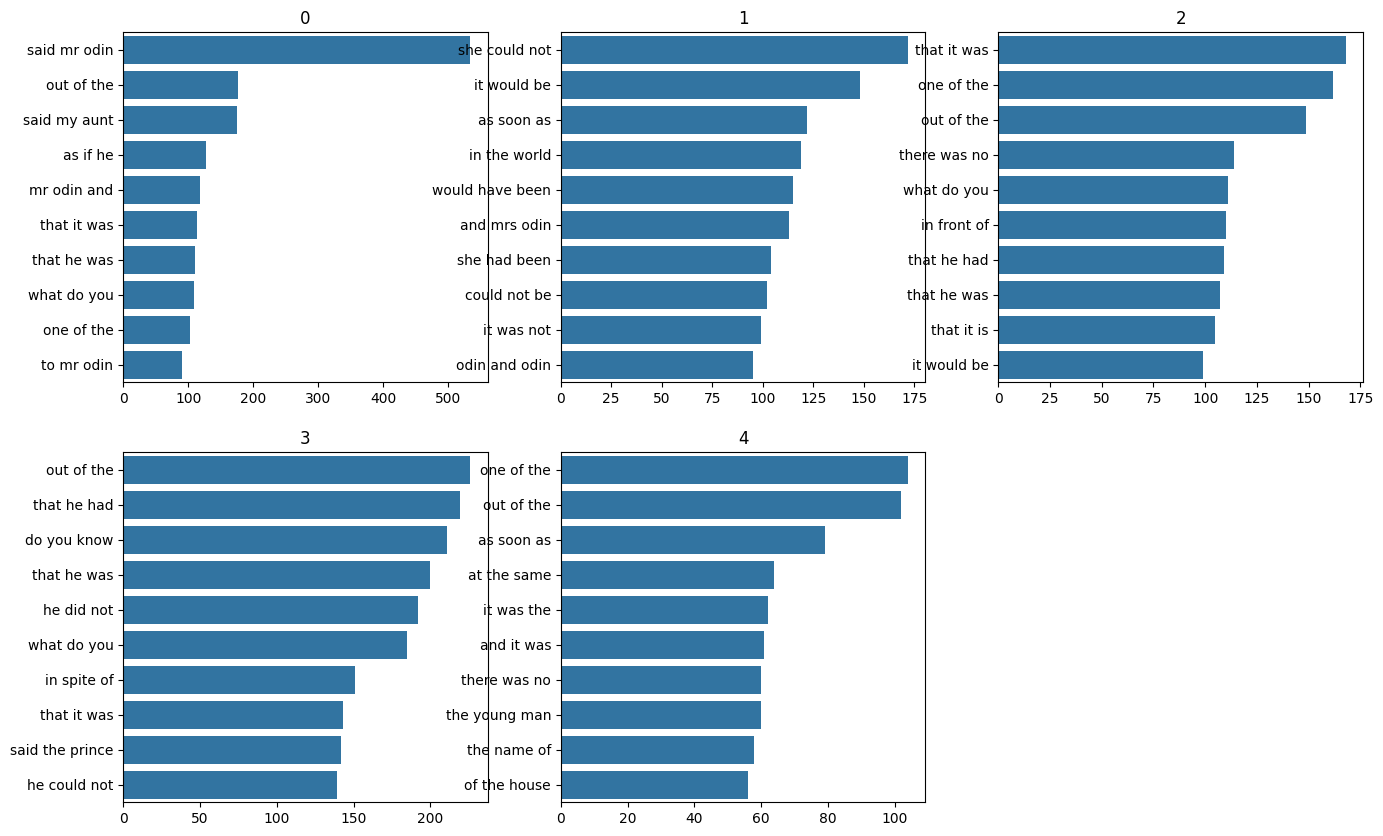

In [ ]:
fig = plt.figure(figsize=(16,10)) # rows*cols 행렬의 i번째 subplot 생성
rows = 2
cols = 3

def plot_top_ngrams_barchart2(text, n=2):
    stop=set(stopwords.words('english'))

    new= text.str.split()
    new=new.values.tolist()
    corpus=[word for i in new for word in i]

    def _get_top_ngram(corpus, n=None):
        vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx])
                      for word, idx in vec.vocabulary_.items()]
        words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
        return words_freq[:10]

    top_n_bigrams=_get_top_ngram(text,n)[:10]
    x,y=map(list,zip(*top_n_bigrams))

    return x, y

for i in range(5):
    x,y = plot_top_ngrams_barchart2(X_train[X_train['author']==i]['text_l'], n=3)
    ax = fig.add_subplot(rows, cols, i+1)
    ax.set_title(i)
    sns.barplot(x=y,y=x)

### wordcloud

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from nltk.stem import WordNetLemmatizer,PorterStemmer

In [ ]:
stop = set(stopwords.words('english'))

def plot_wordcloud(text):


    def _preprocess_text(text):
        corpus=[]
        stem = PorterStemmer()
        lem = WordNetLemmatizer()
        for news in text:
            words = [w for w in word_tokenize(news) if (w not in stop)]
            words = [lem.lemmatize(w) for w in words if len(w)>2]
            corpus.append(words)
        return corpus

    corpus=_preprocess_text(text)

    wordcloud = WordCloud(
        background_color='white',
        stopwords=set(STOPWORDS),
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1)

    wordcloud=wordcloud.generate(str(corpus))

    return wordcloud

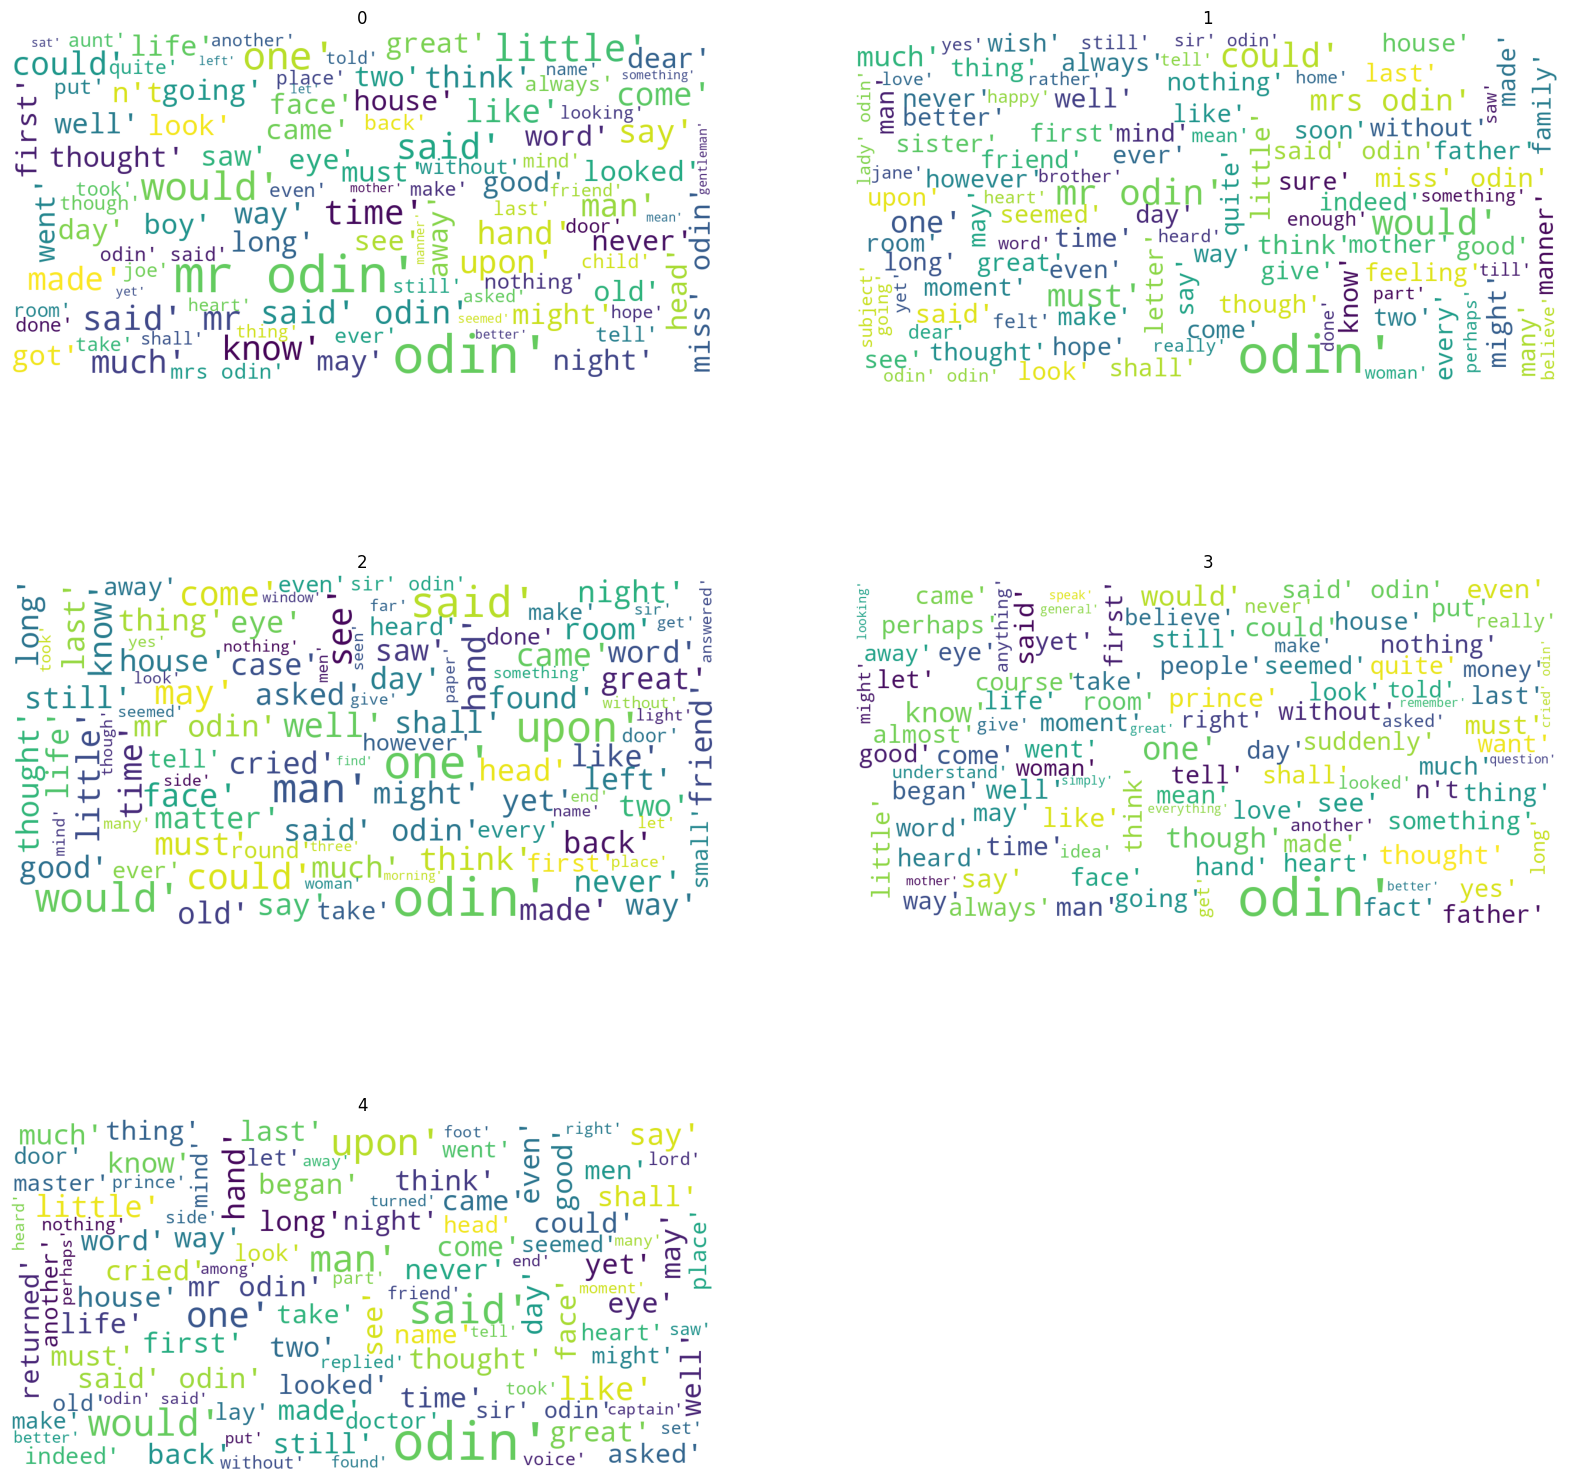

In [ ]:
fig = plt.figure(figsize=(20,20)) # rows*cols 행렬의 i번째 subplot 생성
rows = 3
cols = 2

for i in range(5):
    wordcloud = plot_wordcloud(X_train[X_train['author']==i]['text_l'])
    ax = fig.add_subplot(rows, cols, i+1)

    ax.axis('off')
    ax.set_title(i)
    ax.imshow(wordcloud)

In [ ]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# noun
def plot_wordcloud_noun(text,tags=['NN','NNP']):

    def _preprocess_text(text,tags):
        corpus=[]
        stem=PorterStemmer()
        lem=WordNetLemmatizer()
        for news in text:
            words=[w for w in word_tokenize(news) if (w not in stop)]
            words=[lem.lemmatize(w) for w in words if len(w)>2]

            tagged = nltk.pos_tag(words)
            allnoun = [word for word, pos in tagged if pos in tags]

            corpus.append(allnoun)
        return corpus

    corpus=_preprocess_text(text,tags)

    wordcloud = WordCloud(
        background_color='white',
        stopwords=set(STOPWORDS),
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1)

    wordcloud=wordcloud.generate(str(corpus))

    return wordcloud

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
wordcloud = plot_wordcloud_noun(X_test['text_l'])

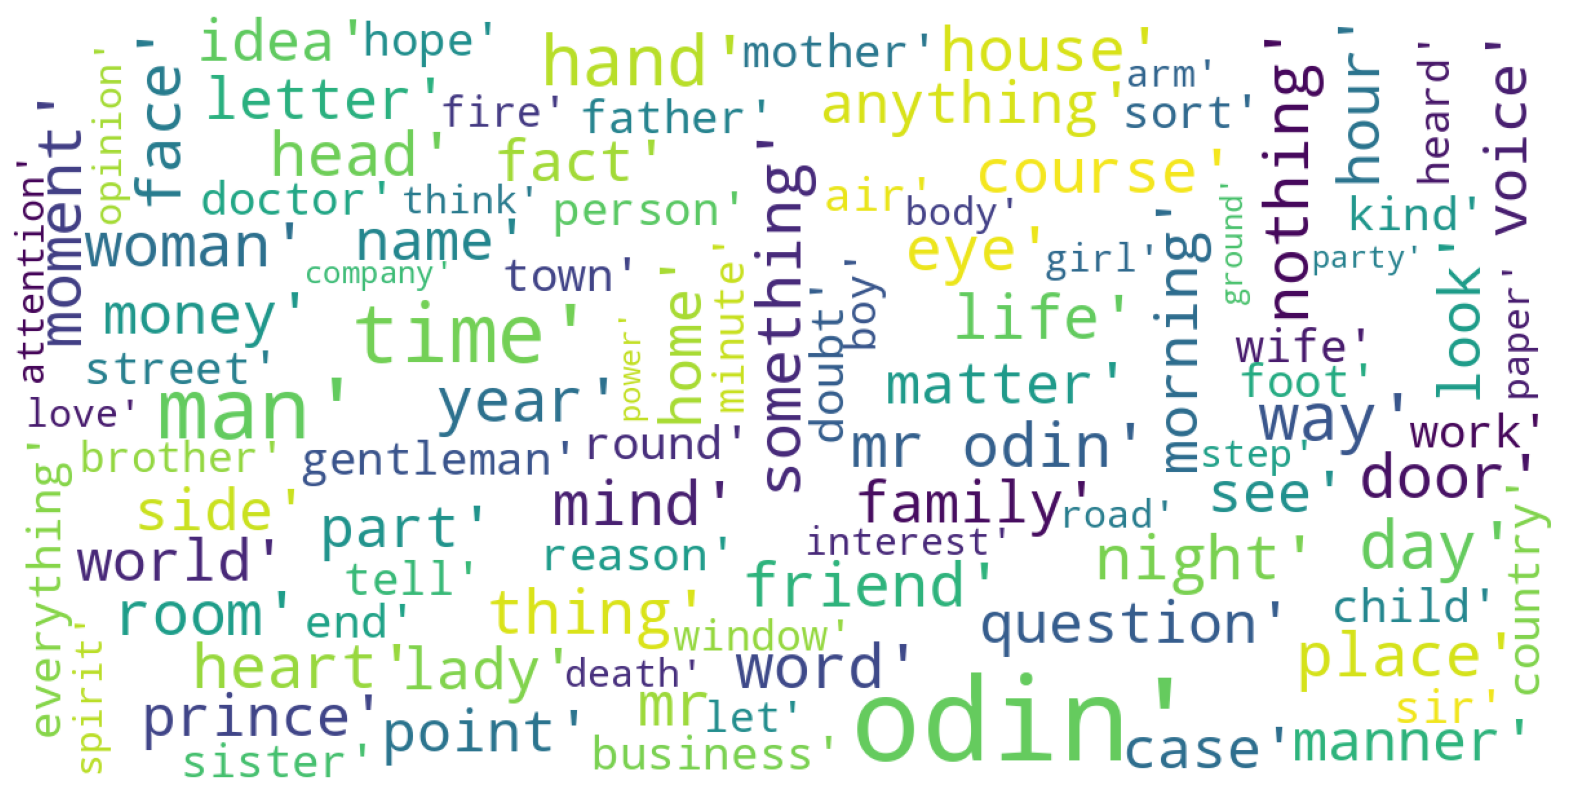

In [ ]:
fig, ax = plt.subplots(figsize=(20, 15))
ax.axis('off')
ax.imshow(wordcloud)